# 02 — Weight of Evidence (WoE) Binning

Transform continuous features into WoE values — the standard approach
in credit risk modelling under Basel II/III frameworks.

Outputs:
- WoE-transformed feature matrix
- Information Value (IV) ranking for feature selection
- Bin boundary documentation

In [7]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from woe_encoder import WoEEncoder

sns.set_style("whitegrid")
%matplotlib inline

In [8]:
df = pd.read_csv("../data/processed/train_features.csv")
target = "TARGET"
exclude = ["SK_ID_CURR", "SK_ID_PREV", target]

numeric_cols = df.select_dtypes(include="number").columns.drop(exclude, errors="ignore").tolist()
X = df[numeric_cols]
y = df[target]

print(f"Features: {len(numeric_cols)} | Rows: {len(df):,}")

Features: 298 | Rows: 307,511


## Fit WoE Encoder

In [9]:
encoder = WoEEncoder(bins=10, min_bin_size=0.05)
X_woe = encoder.fit_transform(X, y)

print("WoE transformation complete.")
X_woe.head()

WoE transformation complete.


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,FREQ_ORGANIZATION_TYPE,FREQ_FONDKAPREMONT_MODE,FREQ_HOUSETYPE_MODE,FREQ_WALLSMATERIAL_MODE,FREQ_latest_app_status,WORST_DPD_ALL,TOTAL_DPD_MONTHS,BUREAU_RISK_SCORE,PAYMENT_DISCIPLINE,TOTAL_EXPOSURE_RATIO
0,0.012642,0.036358,-0.239090,-0.053119,-0.241814,-0.172132,-0.399803,-0.371429,-0.081118,-0.114963,...,-0.154932,0.160691,0.000018,-0.061933,0.093714,0.066416,-0.229203,0.116497,0.179357,-0.019022
1,0.012642,0.147763,0.444701,-0.068874,0.530594,-0.065684,0.038263,-0.288526,-0.124323,-0.253847,...,-0.038145,0.160691,0.000018,-0.061933,0.093714,0.066416,0.053679,0.328503,0.179357,0.015026
2,0.012642,-0.015918,0.197529,0.138066,0.110946,0.048464,0.260101,-0.370257,-0.081118,-0.114963,...,0.101496,-0.062100,0.000018,-0.061933,0.093714,0.066416,0.053679,0.328503,0.179357,-0.086962
3,0.012642,-0.054925,-0.239090,-0.244344,-0.241814,-0.155306,0.260101,0.125730,0.213334,-0.114963,...,-0.154932,-0.062100,0.000018,-0.061933,-0.255458,0.066416,0.053679,NaN,0.179357,-0.169506
4,0.012642,-0.054925,-0.188886,-0.080274,0.226612,0.083847,0.260101,0.125730,-0.081118,0.039737,...,0.022666,-0.062100,0.000018,-0.061933,0.093714,0.066416,0.053679,0.328503,-0.281843,-0.086962


## Information Value Summary

IV interpretation (industry standard):
- < 0.02 → Useless
- 0.02–0.1 → Weak
- 0.1–0.3 → Medium
- 0.3–0.5 → Strong
- > 0.5 → Suspicious (possible info leakage)

In [10]:
iv_summary = encoder.get_iv_summary()
print(f"Features by predictive power:\n")
print(iv_summary.groupby("Predictive_Power").size().to_string())
print(f"\nTop 20 features by IV:\n")
iv_summary.head(20)

Features by predictive power:

Predictive_Power
Medium         19
Strong         10
Suspicious      6
Useless       164
Weak           99

Top 20 features by IV:



,IV,Predictive_Power
EXT_SRC_PROD,0.772511,Suspicious
EXT_SOURCE_WEIGHTED,0.703639,Suspicious
EXT_SRC_1x3,0.649514,Suspicious
EXT_SRC_2x3,0.613939,Suspicious
EXT_SOURCE_MEAN,0.608452,Suspicious
EXT_SRC_1x2,0.508355,Suspicious
EXT_SOURCE_MIN,0.466131,Strong
EXT_SOURCE_MAX,0.442499,Strong
EXT_SRC3_x_AGE,0.424787,Strong
EXT_SRC3_SQ,0.409969,Strong


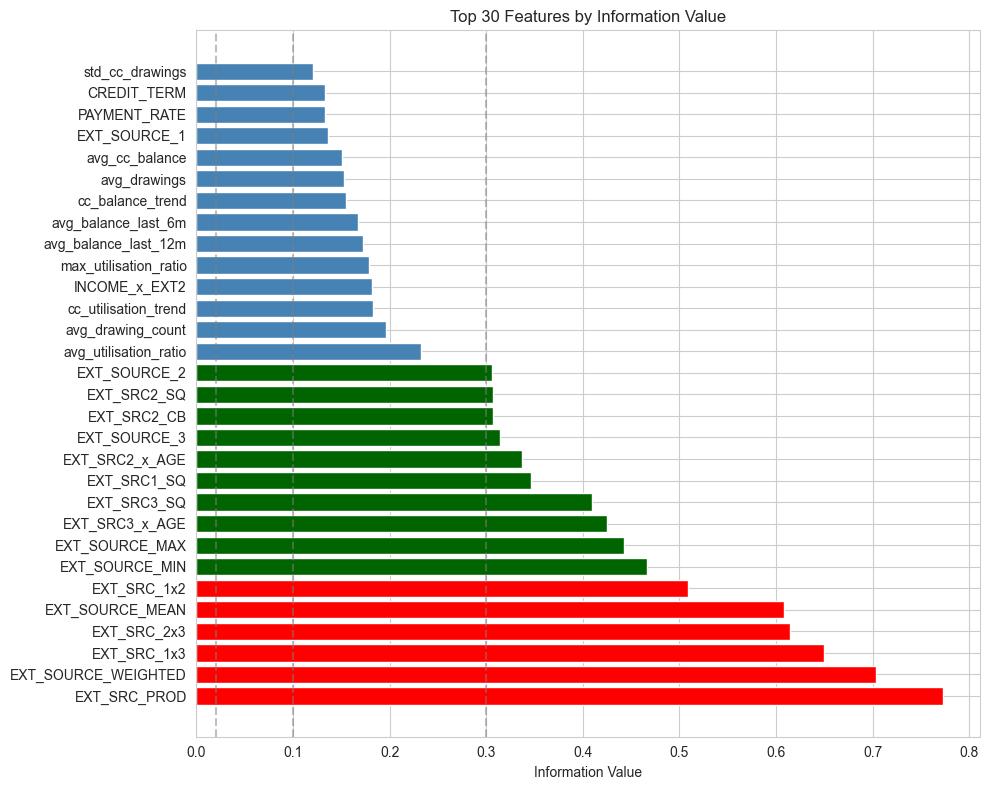

In [11]:
# IV bar chart — top 30
fig, ax = plt.subplots(figsize=(10, 8))
top_iv = iv_summary.head(30)
colors = top_iv["Predictive_Power"].map({
    "Strong": "darkgreen", "Medium": "steelblue",
    "Weak": "orange", "Useless": "lightgray", "Suspicious": "red"
})
ax.barh(top_iv.index, top_iv["IV"], color=colors)
ax.set_xlabel("Information Value")
ax.set_title("Top 30 Features by Information Value")
ax.axvline(x=0.02, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0.1, color="gray", linestyle="--", alpha=0.5)
ax.axvline(x=0.3, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Feature Selection Based on IV

Select features with IV ≥ 0.02 (discard "Useless" variables).

In [12]:
selected_features = iv_summary[iv_summary["IV"] >= 0.02].index.tolist()
print(f"Selected {len(selected_features)} of {len(numeric_cols)} features (IV >= 0.02)")

# Save for downstream notebooks
X_woe_selected = X_woe[selected_features]
X_woe_selected.to_csv("../data/processed/X_woe.csv", index=False)
iv_summary.to_csv("../data/processed/iv_summary.csv")
print("Saved X_woe.csv and iv_summary.csv")

Selected 134 of 298 features (IV >= 0.02)
Saved X_woe.csv and iv_summary.csv
